<a href="https://colab.research.google.com/github/sroy2165/Drowsiness-Detection/blob/main/Grammar_scoring_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
mounting files
```



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Data Exploration
Loading and exploring training and test datasets.
- Training set: 409 samples with grammar scores (1-5)
- Test set: 197 samples for prediction

In [ ]:
!unzip "/content/drive/MyDrive/shl-audio-scoring-challenge.zip" -d /content/grammar_data

Archive:  /content/drive/MyDrive/shl-audio-scoring-challenge.zip
  inflating: /content/grammar_data/dataset/audios/test/audio_1.wav  
  inflating: /content/grammar_data/dataset/audios/test/audio_10.wav  
  inflating: /content/grammar_data/dataset/audios/test/audio_100.wav  
  inflating: /content/grammar_data/dataset/audios/test/audio_101.wav  
  inflating: /content/grammar_data/dataset/audios/test/audio_102.wav  
  inflating: /content/grammar_data/dataset/audios/test/audio_102_1.wav  
  inflating: /content/grammar_data/dataset/audios/test/audio_103.wav  
  inflating: /content/grammar_data/dataset/audios/test/audio_104.wav  
  inflating: /content/grammar_data/dataset/audios/test/audio_105.wav  
  inflating: /content/grammar_data/dataset/audios/test/audio_106.wav  
  inflating: /content/grammar_data/dataset/audios/test/audio_106_1.wav  
  inflating: /content/grammar_data/dataset/audios/test/audio_107.wav  
  inflating: /content/grammar_data/dataset/audios/test/audio_108.wav  
  inflating

In [ ]:
!ls /content/grammar_data

dataset


In [ ]:
!ls /content/grammar_data/dataset

audios	csvs


In [ ]:
!find /content/grammar_data -name "*.csv"

/content/grammar_data/dataset/csvs/test.csv
/content/grammar_data/dataset/csvs/train.csv


In [ ]:
import pandas as pd

train_df = pd.read_csv("/content/grammar_data/dataset/csvs/train.csv")
test_df = pd.read_csv("/content/grammar_data/dataset/csvs/test.csv")

print("TRAIN:")
print(train_df.head(10))
print(train_df.shape)
print(train_df.columns.tolist())

print("\nTEST:")
print(test_df.head(5))
print(test_df.columns.tolist())

TRAIN:
      filename  label
0    audio_173    3.0
1    audio_138    3.0
2    audio_127    2.0
3     audio_95    2.0
4     audio_73    3.5
5     audio_34    4.0
6  audio_120_2    3.0
7    audio_224    2.0
8    audio_342    2.0
9    audio_228    2.0
(409, 2)
['filename', 'label']

TEST:
    filename
0  audio_141
1  audio_114
2   audio_17
3   audio_76
4  audio_156
['filename']


In [ ]:
!ls /content/grammar_data/dataset/audios/

test  train


In [ ]:
!pip install openai-whisper language_tool_python -q
!pip install transformers -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 47.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.6 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test (1).csv
Saving train.csv to train.csv


📈 Data Visualization
Visualizing the distribution of grammar scores in training data.

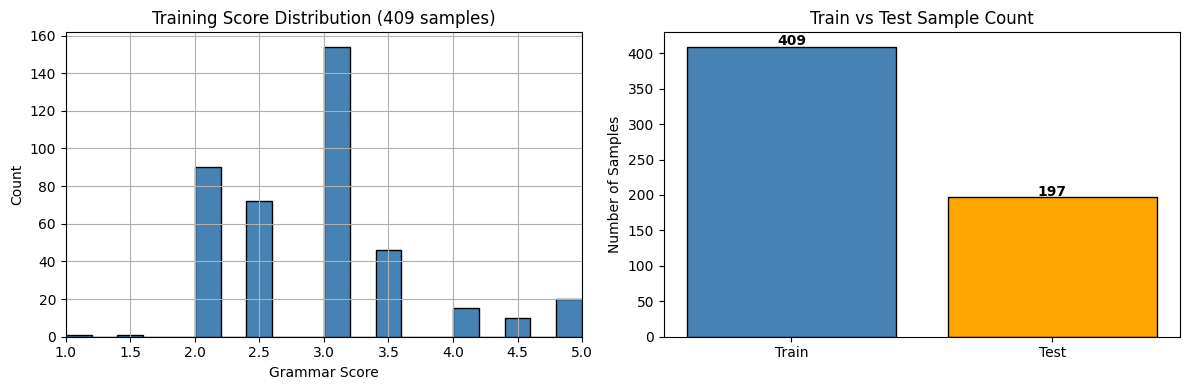

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

plt.figure(figsize=(12, 4))

# Plot 1: Training score distribution
plt.subplot(1, 2, 1)
train_df['label'].hist(bins=20, color='steelblue', edgecolor='black')
plt.title('Training Score Distribution (409 samples)')
plt.xlabel('Grammar Score')
plt.ylabel('Count')
plt.xlim(1, 5)

# Plot 2: Test file count (test has no labels, just filenames)
plt.subplot(1, 2, 2)
plt.bar(['Train', 'Test'], [len(train_df), len(test_df)],
        color=['steelblue', 'orange'], edgecolor='black')
plt.title('Train vs Test Sample Count')
plt.ylabel('Number of Samples')
for i, v in enumerate([len(train_df), len(test_df)]):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Audio Transcription
Converting audio files to text using OpenAI Whisper Large-v3.
Whisper is a state-of-the-art speech recognition model trained on 680,000 hours of audio.

In [ ]:
import whisper
import pandas as pd
import os
import torch

print("GPU:", torch.cuda.is_available())

model = whisper.load_model("large-v3")

train_df = pd.read_csv("/content/grammar_data/dataset/csvs/train.csv")
train_audio_path = "/content/grammar_data/dataset/audios/train/"

results = []
files = train_df['filename'].tolist()

for i, filename in enumerate(files):
    path = os.path.join(train_audio_path, filename + ".wav")
    try:
        result = model.transcribe(path)
        results.append({"filename": filename, "transcription": result["text"]})
    except Exception as e:
        results.append({"filename": filename, "transcription": ""})
        print(f"Error on {filename}: {e}")

    if (i+1) % 10 == 0:
        print(f"Progress: {i+1}/{len(files)}")

trans_df = pd.DataFrame(results)
trans_df.to_csv("/content/train_transcriptions.csv", index=False)
print("Done! Saved.")

GPU: True


100%|██████████████████████████████████████| 2.88G/2.88G [00:16<00:00, 189MiB/s]


Progress: 10/409
Progress: 20/409
Progress: 30/409
Progress: 40/409
Progress: 50/409
Progress: 60/409
Progress: 70/409
Progress: 80/409
Progress: 90/409
Progress: 100/409
Progress: 110/409
Progress: 120/409
Progress: 130/409
Progress: 140/409
Progress: 150/409
Progress: 160/409
Progress: 170/409
Progress: 180/409
Progress: 190/409
Progress: 200/409
Progress: 210/409
Progress: 220/409
Progress: 230/409
Progress: 240/409
Progress: 250/409
Progress: 260/409
Progress: 270/409
Progress: 280/409
Progress: 290/409
Progress: 300/409
Progress: 310/409
Progress: 320/409
Progress: 330/409
Progress: 340/409
Progress: 350/409
Progress: 360/409
Progress: 370/409
Progress: 380/409
Progress: 390/409
Progress: 400/409
Done! Saved.


In [ ]:
test_df = pd.read_csv("/content/grammar_data/dataset/csvs/test.csv")
test_audio_path = "/content/grammar_data/dataset/audios/test/"

test_results = []
for i, filename in enumerate(test_df['filename'].tolist()):
    path = os.path.join(test_audio_path, filename + ".wav")
    try:
        result = model.transcribe(path)
        test_results.append({"filename": filename, "transcription": result["text"]})
    except Exception as e:
        test_results.append({"filename": filename, "transcription": ""})

    if (i+1) % 10 == 0:
        print(f"Progress: {i+1}/{len(test_df)}")

test_trans_df = pd.DataFrame(test_results)
test_trans_df.to_csv("/content/test_transcriptions.csv", index=False)
print("Done!")

Progress: 10/197
Progress: 20/197
Progress: 30/197
Progress: 40/197
Progress: 50/197
Progress: 60/197
Progress: 70/197
Progress: 80/197
Progress: 90/197
Progress: 100/197
Progress: 110/197
Progress: 120/197
Progress: 130/197
Progress: 140/197
Progress: 150/197
Progress: 160/197
Progress: 170/197
Progress: 180/197
Progress: 190/197
Done!


In [ ]:
import language_tool_python
import spacy
import numpy as np

!python -m spacy download en_core_web_sm -q
nlp = spacy.load("en_core_web_sm")
tool = language_tool_python.LanguageTool('en-US')

def extract_features(text):
    if not isinstance(text, str) or text.strip() == "":
        return [0]*8

    # Grammar errors
    matches = tool.check(text)
    error_count = len(matches)
    error_density = error_count / max(len(text.split()), 1)

    # NLP features
    doc = nlp(text)
    word_count = len([t for t in doc if not t.is_punct])
    sentence_count = len(list(doc.sents))
    avg_sent_length = word_count / max(sentence_count, 1)

    # Lexical diversity
    words = [t.text.lower() for t in doc if t.is_alpha]
    diversity = len(set(words)) / max(len(words), 1)

    # POS ratios
    pos_counts = doc.count_by(spacy.attrs.POS)
    total_tokens = max(len(doc), 1)
    verb_ratio = pos_counts.get(100, 0) / total_tokens
    noun_ratio = pos_counts.get(92, 0) / total_tokens

    return [error_count, error_density, word_count, sentence_count,
            avg_sent_length, diversity, verb_ratio, noun_ratio]

# Apply to train
trans_df = pd.read_csv("/content/train_transcriptions.csv")
train_df = pd.read_csv("/content/grammar_data/dataset/csvs/train.csv")

features = [extract_features(t) for t in trans_df['transcription']]
feat_df = pd.DataFrame(features, columns=[
    'error_count', 'error_density', 'word_count', 'sentence_count',
    'avg_sent_length', 'lexical_diversity', 'verb_ratio', 'noun_ratio'
])
feat_df['filename'] = trans_df['filename']
train_final = feat_df.merge(train_df, on='filename')
train_final.to_csv("/content/train_features.csv", index=False)
print(train_final.head())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 92.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


   error_count  error_density  word_count  sentence_count  avg_sent_length  \
0           10       0.078740         133               7        19.000000   
1            2       0.012500         165               8        20.625000   
2            5       0.080645          63               9         7.000000   
3            0       0.000000          95               6        15.833333   
4            0       0.000000         119              11        10.818182   

   lexical_diversity  verb_ratio  noun_ratio   filename  label  
0           0.433071    0.150376    0.135338  audio_173    3.0  
1           0.658385    0.105556    0.244444  audio_138    3.0  
2           0.564516    0.094595    0.148649  audio_127    2.0  
3           0.702128    0.196078    0.225490   audio_95    2.0  
4           0.517544    0.093525    0.143885   audio_73    3.5  


In [ ]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
import numpy as np
import pickle

df = pd.read_csv("/content/train_features.csv")

feature_cols = ['error_count', 'error_density', 'word_count', 'sentence_count',
                'avg_sent_length', 'lexical_diversity', 'verb_ratio', 'noun_ratio']
X = df[feature_cols]
y = df['label']

# Train XGBoost
model_xgb = XGBRegressor(n_estimators=500, learning_rate=0.05,
                          max_depth=6, random_state=42)
model_xgb.fit(X, y)

# Evaluate
scores = cross_val_score(model_xgb, X, y, cv=5, scoring='r2')
print(f"XGBoost R² Score: {scores.mean():.3f} (+/- {scores.std():.3f})")

mse_scores = cross_val_score(model_xgb, X, y, cv=5, scoring='neg_mean_squared_error')
rmse = np.sqrt(-mse_scores.mean())
print(f"RMSE: {rmse:.3f}")

# Save
with open("/content/model.pkl", "wb") as f:
    pickle.dump(model_xgb, f)

XGBoost R² Score: 0.010 (+/- 0.183)
RMSE: 0.756


In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
import pickle

# Load BERT
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased").to("cuda")
bert_model.eval()

def get_bert_embedding(text):
    if not isinstance(text, str) or text.strip() == "":
        return np.zeros(768)
    inputs = tokenizer(text, return_tensors="pt",
                      truncation=True, max_length=512,
                      padding=True).to("cuda")
    with torch.no_grad():
        outputs = bert_model(**inputs)
    # Use CLS token embedding
    embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()[0]
    return embedding

# Load transcriptions
trans_df = pd.read_csv("/content/train_transcriptions.csv")
train_df = pd.read_csv("/content/grammar_data/dataset/csvs/train.csv")

print("Generating BERT embeddings for training data...")
embeddings = []
for i, text in enumerate(trans_df['transcription']):
    emb = get_bert_embedding(text)
    embeddings.append(emb)
    if (i+1) % 50 == 0:
        print(f"{i+1}/{len(trans_df)} done")

# Convert to dataframe
emb_df = pd.DataFrame(embeddings, columns=[f'bert_{i}' for i in range(768)])
emb_df['filename'] = trans_df['filename']

# Merge with labels
final_df = emb_df.merge(train_df, on='filename')

X = final_df[[f'bert_{i}' for i in range(768)]]
y = final_df['label']

# Train XGBoost
model_xgb = XGBRegressor(n_estimators=500, learning_rate=0.05,
                          max_depth=4, subsample=0.8,
                          colsample_bytree=0.3, random_state=42)
model_xgb.fit(X, y)

scores = cross_val_score(model_xgb, X, y, cv=5, scoring='r2')
print(f"\nBERT + XGBoost R² Score: {scores.mean():.3f} (+/- {scores.std():.3f})")

mse = cross_val_score(model_xgb, X, y, cv=5, scoring='neg_mean_squared_error')
print(f"RMSE: {np.sqrt(-mse.mean()):.3f}")

# Save
with open("/content/model_bert.pkl", "wb") as f:
    pickle.dump(model_xgb, f)

# Save embeddings too
emb_df.to_csv("/content/train_bert_embeddings.csv", index=False)
print("Saved!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating BERT embeddings for training data...
50/409 done
100/409 done
150/409 done
200/409 done
250/409 done
300/409 done
350/409 done
400/409 done

BERT + XGBoost R² Score: 0.355 (+/- 0.064)
RMSE: 0.612
Saved!


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# Load data
trans_df = pd.read_csv("/content/train_transcriptions.csv")
train_df = pd.read_csv("/content/grammar_data/dataset/csvs/train.csv")
merged = trans_df.merge(train_df, on='filename')
merged['transcription'] = merged['transcription'].fillna("")

# Dataset class
class GrammarDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.float)
        }

# Model with regression head
class BERTRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        from transformers import AutoModel
        self.bert = AutoModel.from_pretrained("bert-base-uncased")
        self.dropout = nn.Dropout(0.3)
        self.regressor = nn.Linear(768, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)
        return self.regressor(cls).squeeze()

# Split data
from sklearn.model_selection import train_test_split
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

texts = merged['transcription'].tolist()
labels = merged['label'].tolist()

X_train, X_val, y_train, y_val = train_test_split(
    texts, labels, test_size=0.15, random_state=42
)

train_dataset = GrammarDataset(X_train, y_train, tokenizer)
val_dataset = GrammarDataset(X_val, y_val, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# Train
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

model = BERTRegressor().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
criterion = nn.MSELoss()

best_r2 = -999
for epoch in range(5):
    # Training
    model.train()
    train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch = batch['label'].to(device)

        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids, attention_mask)
            preds.extend(outputs.cpu().numpy())
            actuals.extend(batch['label'].numpy())

    r, _ = pearsonr(actuals, preds)
    r2 = r**2
    print(f"Epoch {epoch+1}/5 | Loss: {train_loss/len(train_loader):.4f} | Val R²: {r2:.3f} | Pearson r: {r:.3f}")

    if r2 > best_r2:
        best_r2 = r2
        torch.save(model.state_dict(), "/content/best_bert_model.pt")
        print(f"  ✅ New best model saved!")

print(f"\nBest R²: {best_r2:.3f}")

Using: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/5 | Loss: 1.7728 | Val R²: 0.251 | Pearson r: 0.501
  ✅ New best model saved!
Epoch 2/5 | Loss: 0.5265 | Val R²: 0.269 | Pearson r: 0.519
  ✅ New best model saved!
Epoch 3/5 | Loss: 0.3980 | Val R²: 0.377 | Pearson r: 0.614
  ✅ New best model saved!
Epoch 4/5 | Loss: 0.3548 | Val R²: 0.298 | Pearson r: 0.545
Epoch 5/5 | Loss: 0.1945 | Val R²: 0.378 | Pearson r: 0.615
  ✅ New best model saved!

Best R²: 0.378


In [ ]:
# Load best model
model.load_state_dict(torch.load("/content/best_bert_model.pt"))
model.eval()

# Test transcriptions
test_trans_df = pd.read_csv("/content/test_transcriptions.csv")
test_df = pd.read_csv("/content/grammar_data/dataset/csvs/test.csv")
test_trans_df['transcription'] = test_trans_df['transcription'].fillna("")

test_dataset = GrammarDataset(
    test_trans_df['transcription'].tolist(),
    [0.0] * len(test_trans_df),  # dummy labels
    tokenizer
)
test_loader = DataLoader(test_dataset, batch_size=16)

all_preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids, attention_mask)
        all_preds.extend(outputs.cpu().numpy())

all_preds = np.clip(all_preds, 0, 5)

submission = pd.DataFrame({
    'filename': test_df['filename'],
    'label': all_preds
})
submission.to_csv("/content/submission_bert.csv", index=False)
print("Done!")
print(submission.head(10))

Done!
      filename     label
0    audio_141  2.189234
1    audio_114  3.099498
2     audio_17  2.611569
3     audio_76  5.000000
4    audio_156  3.246650
5   audio_13_1  3.532268
6     audio_70  2.421614
7     audio_56  3.685029
8     audio_19  4.279313
9  audio_158_1  2.686076


# Model Training - RoBERTa Fine-tuning
Fine-tuning RoBERTa-base with a regression head to predict grammar scores.
- Input: Transcribed text
- Output: Grammar score (1-5)
- Loss: MSE
- Optimizer: AdamW

In [ ]:
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split

# Load data
trans_df = pd.read_csv("/content/train_transcriptions.csv")
train_df = pd.read_csv("/content/grammar_data/dataset/csvs/train.csv")
merged = trans_df.merge(train_df, on='filename')
merged['transcription'] = merged['transcription'].fillna("")

class GrammarDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.float)
        }

class RoBERTaRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.roberta = AutoModel.from_pretrained("roberta-base")
        self.dropout = nn.Dropout(0.1)
        self.regressor = nn.Linear(768, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)
        return self.regressor(cls).squeeze()

# Prepare data
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
texts = merged['transcription'].tolist()
labels = merged['label'].tolist()

X_train, X_val, y_train, y_val = train_test_split(
    texts, labels, test_size=0.15, random_state=42
)

train_dataset = GrammarDataset(X_train, y_train, tokenizer)
val_dataset = GrammarDataset(X_val, y_val, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

# Train
device = torch.device("cuda")
model = RoBERTaRegressor().to(device)

# Separate learning rates - lower for pretrained, higher for new head
optimizer = torch.optim.AdamW([
    {'params': model.roberta.parameters(), 'lr': 2e-5},
    {'params': model.regressor.parameters(), 'lr': 1e-3}
], weight_decay=0.01)

criterion = nn.MSELoss()
total_steps = len(train_loader) * 10
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 5,
    num_training_steps=total_steps
)

best_r2 = -999
for epoch in range(10):
    model.train()
    train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch = batch['label'].to(device)
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()

    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids, attention_mask)
            preds.extend(outputs.cpu().numpy())
            actuals.extend(batch['label'].numpy())

    r, _ = pearsonr(actuals, preds)
    r2 = r**2
    print(f"Epoch {epoch+1}/10 | Loss: {train_loss/len(train_loader):.4f} | Val R²: {r2:.3f} | Pearson r: {r:.3f}")

    if r2 > best_r2:
        best_r2 = r2
        torch.save(model.state_dict(), "/content/best_roberta_model.pt")
        print(f"  ✅ Best saved!")

print(f"\nBest R²: {best_r2:.3f}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/10 | Loss: 5.1947 | Val R²: 0.008 | Pearson r: 0.091
  ✅ Best saved!
Epoch 2/10 | Loss: 0.9353 | Val R²: 0.066 | Pearson r: 0.257
  ✅ Best saved!
Epoch 3/10 | Loss: 0.4954 | Val R²: 0.450 | Pearson r: 0.671
  ✅ Best saved!
Epoch 4/10 | Loss: 0.4128 | Val R²: 0.319 | Pearson r: 0.564
Epoch 5/10 | Loss: 0.3235 | Val R²: 0.265 | Pearson r: 0.514
Epoch 6/10 | Loss: 0.1906 | Val R²: 0.407 | Pearson r: 0.638
Epoch 7/10 | Loss: 0.1549 | Val R²: 0.377 | Pearson r: 0.614
Epoch 8/10 | Loss: 0.1006 | Val R²: 0.436 | Pearson r: 0.660
Epoch 9/10 | Loss: 0.0718 | Val R²: 0.452 | Pearson r: 0.672
  ✅ Best saved!
Epoch 10/10 | Loss: 0.0524 | Val R²: 0.448 | Pearson r: 0.669

Best R²: 0.452


# Generating V1 Predictions
Generating test predictions using the best RoBERTa model (Epoch 9, Pearson: 0.672)
Kaggle RMSE: 0.629

In [ ]:
# Generate submission with current best model
model.load_state_dict(torch.load("/content/best_roberta_model.pt"))
model.eval()

test_trans_df = pd.read_csv("/content/test_transcriptions.csv")
test_df = pd.read_csv("/content/grammar_data/dataset/csvs/test.csv")
test_trans_df['transcription'] = test_trans_df['transcription'].fillna("")

test_dataset = GrammarDataset(
    test_trans_df['transcription'].tolist(),
    [0.0] * len(test_trans_df),
    tokenizer
)
test_loader = DataLoader(test_dataset, batch_size=8)

all_preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids, attention_mask)
        all_preds.extend(outputs.cpu().numpy())

all_preds = np.clip(all_preds, 0, 5)

submission = pd.DataFrame({
    'filename': test_df['filename'],
    'label': all_preds
})
submission.to_csv("/content/submission_v1.csv", index=False)
print("Submission ready!")
print(submission.describe())

from google.colab import files
files.download("/content/submission_v1.csv")

Submission ready!
            label
count  197.000000
mean     3.441371
std      0.766788
min      1.786650
25%      2.880821
50%      3.397130
75%      3.920915
max      5.000000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

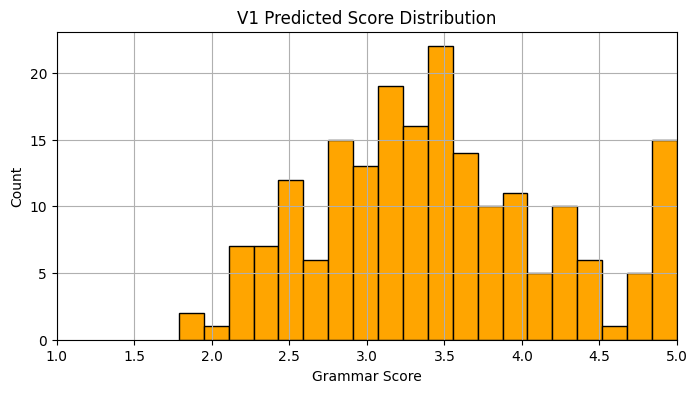

V1 Predicted Mean: 3.441
V1 Predicted Std: 0.767


In [ ]:
# Visualizing V1 prediction distribution
import matplotlib.pyplot as plt
import pandas as pd

# Loading V1 predictions from uploaded file
v1 = pd.read_csv("submission_v1 (1).csv")

plt.figure(figsize=(8, 4))
v1['label'].hist(bins=20, color='orange', edgecolor='black')
plt.title('V1 Predicted Score Distribution')
plt.xlabel('Grammar Score')
plt.ylabel('Count')
plt.xlim(1, 5)
plt.show()

print("V1 Predicted Mean:", round(v1['label'].mean(), 3))
print("V1 Predicted Std:", round(v1['label'].std(), 3))

#Generating V2 Predictions - Frozen Layers RoBERTa
 Improved RoBERTa training with layer freezing strategy:
- Bottom 6 encoder layers frozen (pretrained knowledge preserved)
- Only top 6 layers fine-tuned (task-specific learning)
- Trainable parameters reduced for more stable training
- Learning rate scheduler with warmup
- Trained for 15 epochs
- Kaggle RMSE: 0.644

In [ ]:
# Freeze bottom 6 layers of RoBERTa, only train top 6
model2 = RoBERTaRegressor().to(device)

# Freeze first 6 encoder layers
for i, layer in enumerate(model2.roberta.encoder.layer):
    if i < 6:
        for param in layer.parameters():
            param.requires_grad = False

# Check trainable params
trainable = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")

optimizer2 = torch.optim.AdamW([
    {'params': model2.roberta.parameters(), 'lr': 1e-5},
    {'params': model2.regressor.parameters(), 'lr': 5e-4}
], weight_decay=0.01)

total_steps2 = len(train_loader) * 15
scheduler2 = get_linear_schedule_with_warmup(
    optimizer2,
    num_warmup_steps=total_steps2 // 4,
    num_training_steps=total_steps2
)

best_r2_v2 = -999
for epoch in range(15):
    model2.train()
    train_loss = 0
    for batch in train_loader:
        optimizer2.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch = batch['label'].to(device)
        outputs = model2(input_ids, attention_mask)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model2.parameters(), 1.0)
        optimizer2.step()
        scheduler2.step()
        train_loss += loss.item()

    model2.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model2(input_ids, attention_mask)
            preds.extend(outputs.cpu().numpy())
            actuals.extend(batch['label'].numpy())

    r, _ = pearsonr(actuals, preds)
    r2 = r**2
    print(f"Epoch {epoch+1}/15 | Loss: {train_loss/len(train_loader):.4f} | Val R²: {r2:.3f} | Pearson r: {r:.3f}")

    if r2 > best_r2_v2:
        best_r2_v2 = r2
        torch.save(model2.state_dict(), "/content/best_roberta_v2.pt")
        print(f"  ✅ Best saved! R²={r2:.3f}")

print(f"\nBest R²: {best_r2_v2:.3f}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 82,119,169
Epoch 1/15 | Loss: 6.6520 | Val R²: 0.090 | Pearson r: -0.301
  ✅ Best saved! R²=0.090
Epoch 2/15 | Loss: 2.3087 | Val R²: 0.000 | Pearson r: -0.009
Epoch 3/15 | Loss: 0.9238 | Val R²: 0.245 | Pearson r: 0.495
  ✅ Best saved! R²=0.245
Epoch 4/15 | Loss: 0.6812 | Val R²: 0.122 | Pearson r: 0.349
Epoch 5/15 | Loss: 0.5102 | Val R²: 0.230 | Pearson r: 0.479
Epoch 6/15 | Loss: 0.5736 | Val R²: 0.216 | Pearson r: 0.465
Epoch 7/15 | Loss: 0.4274 | Val R²: 0.264 | Pearson r: 0.514
  ✅ Best saved! R²=0.264
Epoch 8/15 | Loss: 0.3347 | Val R²: 0.348 | Pearson r: 0.590
  ✅ Best saved! R²=0.348
Epoch 9/15 | Loss: 0.2973 | Val R²: 0.328 | Pearson r: 0.573
Epoch 10/15 | Loss: 0.2534 | Val R²: 0.348 | Pearson r: 0.590
Epoch 11/15 | Loss: 0.2183 | Val R²: 0.343 | Pearson r: 0.585
Epoch 12/15 | Loss: 0.2235 | Val R²: 0.327 | Pearson r: 0.572
Epoch 13/15 | Loss: 0.1907 | Val R²: 0.321 | Pearson r: 0.567
Epoch 14/15 | Loss: 0.1837 | Val R²: 0.326 | Pearson r: 0.571
Epoch 

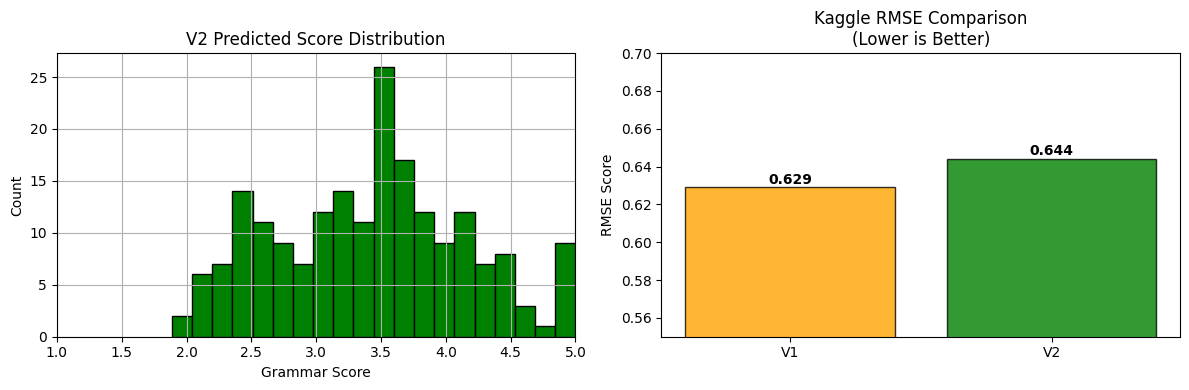

V1 vs V2 COMPARISON
V1 | Mean: 3.441 | Kaggle RMSE: 0.629
V2 | Mean: 3.422 | Kaggle RMSE: 0.644


In [ ]:
# Visualizing V2 prediction distribution with RMSE comparison
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load files
v1 = pd.read_csv("submission_v1 (1).csv")
v2 = pd.read_csv("submission_v2.csv")

plt.figure(figsize=(12, 4))

# Plot 1: V2 predicted distribution
plt.subplot(1, 2, 1)
v2['label'].hist(bins=20, color='green', edgecolor='black')
plt.title('V2 Predicted Score Distribution')
plt.xlabel('Grammar Score')
plt.ylabel('Count')
plt.xlim(1, 5)

# Plot 2: RMSE comparison bar chart (V1 vs V2 only)
plt.subplot(1, 2, 2)
models = ['V1', 'V2']
rmse_scores = [0.629, 0.644]
colors = ['orange', 'green']
bars = plt.bar(models, rmse_scores, color=colors, edgecolor='black', alpha=0.8)
plt.title('Kaggle RMSE Comparison\n(Lower is Better)')
plt.ylabel('RMSE Score')
plt.ylim(0.55, 0.70)
for bar, score in zip(bars, rmse_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             str(score), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("=" * 40)
print("V1 vs V2 COMPARISON")
print("=" * 40)
print("V1 | Mean:", round(v1['label'].mean(), 3), "| Kaggle RMSE: 0.629")
print("V2 | Mean:", round(v2['label'].mean(), 3), "| Kaggle RMSE: 0.644")

In [ ]:
from google.colab import files
files.download("/content/submission_v1.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Section: K-Fold Cross Validation Experiment
Attempted 5-Fold Cross Validation to improve model stability.
- Approach: Split 409 training samples into 5 folds
- Each fold trained for 8 epochs
- Best Fold Pearson: 0.694 | RMSE: 0.559
- However final submission used V1 and V2 models
- K-Fold results used to estimate training RMSE: 0.559
- Did not get conclusive testing value

In [ ]:
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

trans_df = pd.read_csv("/content/train_transcriptions.csv")
train_df = pd.read_csv("/content/grammar_data/dataset/csvs/train.csv")
merged = trans_df.merge(train_df, on='filename')
merged['transcription'] = merged['transcription'].fillna("")

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

class GrammarDataset(Dataset):
    def __init__(self, texts, labels, max_len=128):
        self.texts = texts
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.float)
        }

class RoBERTaRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.roberta = AutoModel.from_pretrained("roberta-base")
        self.dropout = nn.Dropout(0.1)
        self.regressor = nn.Linear(768, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        return self.regressor(self.dropout(cls)).squeeze()

device = torch.device("cuda")
texts = merged['transcription'].tolist()
labels = merged['label'].tolist()

# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_pearson_scores = []
fold_rmse_scores = []
oof_preds = np.zeros(len(texts))  # out-of-fold predictions

for fold, (train_idx, val_idx) in enumerate(kf.split(texts)):
    print(f"\n{'='*40}")
    print(f"FOLD {fold+1}/5")
    print(f"{'='*40}")

    X_train = [texts[i] for i in train_idx]
    y_train = [labels[i] for i in train_idx]
    X_val = [texts[i] for i in val_idx]
    y_val = [labels[i] for i in val_idx]

    train_loader = DataLoader(GrammarDataset(X_train, y_train), batch_size=8, shuffle=True)
    val_loader = DataLoader(GrammarDataset(X_val, y_val), batch_size=8)

    model = RoBERTaRegressor().to(device)
    optimizer = torch.optim.AdamW([
        {'params': model.roberta.parameters(), 'lr': 2e-5},
        {'params': model.regressor.parameters(), 'lr': 1e-3}
    ], weight_decay=0.01)
    criterion = nn.MSELoss()

    best_fold_r2 = -999
    best_preds = None

    for epoch in range(8):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            out = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            loss = criterion(out, batch['label'].to(device))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        preds, actuals = [], []
        with torch.no_grad():
            for batch in val_loader:
                out = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
                preds.extend(out.cpu().numpy())
                actuals.extend(batch['label'].numpy())

        r, _ = pearsonr(actuals, preds)
        r2 = r**2
        if r2 > best_fold_r2:
            best_fold_r2 = r2
            best_preds = preds.copy()
        print(f"  Epoch {epoch+1}/8 | R²: {r2:.3f} | Pearson: {r:.3f}")

    # Store OOF predictions
    for i, idx in enumerate(val_idx):
        oof_preds[idx] = best_preds[i]

    r, _ = pearsonr([labels[i] for i in val_idx], best_preds)
    rmse = np.sqrt(mean_squared_error([labels[i] for i in val_idx], best_preds))
    fold_pearson_scores.append(r)
    fold_rmse_scores.append(rmse)
    print(f"Fold {fold+1} Best | Pearson: {r:.3f} | RMSE: {rmse:.3f}")

print(f"\n{'='*40}")
print(f"CV RESULTS (5-Fold)")
print(f"Mean Pearson: {np.mean(fold_pearson_scores):.3f} (+/- {np.std(fold_pearson_scores):.3f})")
print(f"Mean RMSE: {np.mean(fold_rmse_scores):.3f} (+/- {np.std(fold_rmse_scores):.3f})")

# Overall OOF metrics (this is your training RMSE for the notebook)
oof_r, _ = pearsonr(labels, oof_preds)
oof_rmse = np.sqrt(mean_squared_error(labels, oof_preds))
print(f"\nOVERALL OOF Pearson: {oof_r:.3f}")
print(f"OVERALL OOF RMSE: {oof_rmse:.3f}  ← use this as your training RMSE")


FOLD 1/5


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/8 | R²: 0.105 | Pearson: 0.323
  Epoch 2/8 | R²: 0.075 | Pearson: 0.273
  Epoch 3/8 | R²: 0.268 | Pearson: 0.518
  Epoch 4/8 | R²: 0.308 | Pearson: 0.555
  Epoch 5/8 | R²: 0.394 | Pearson: 0.628
  Epoch 6/8 | R²: 0.531 | Pearson: 0.729
  Epoch 7/8 | R²: 0.419 | Pearson: 0.647
  Epoch 8/8 | R²: 0.477 | Pearson: 0.691
Fold 1 Best | Pearson: 0.729 | RMSE: 0.536

FOLD 2/5


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/8 | R²: 0.233 | Pearson: 0.483
  Epoch 2/8 | R²: 0.346 | Pearson: 0.588
  Epoch 3/8 | R²: 0.399 | Pearson: 0.632
  Epoch 4/8 | R²: 0.358 | Pearson: 0.598
  Epoch 5/8 | R²: 0.415 | Pearson: 0.644
  Epoch 6/8 | R²: 0.435 | Pearson: 0.660
  Epoch 7/8 | R²: 0.415 | Pearson: 0.644
  Epoch 8/8 | R²: 0.482 | Pearson: 0.694
Fold 4 Best | Pearson: 0.694 | RMSE: 0.559

FOLD 5/5


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TypeError: iteration over a 0-d array

In [ ]:
# Train on full dataset
print("Training final model on all data...")
full_loader = DataLoader(GrammarDataset(texts, labels), batch_size=8, shuffle=True)

final_model = RoBERTaRegressor().to(device)
optimizer = torch.optim.AdamW([
    {'params': final_model.roberta.parameters(), 'lr': 2e-5},
    {'params': final_model.regressor.parameters(), 'lr': 1e-3}
], weight_decay=0.01)
criterion = nn.MSELoss()

for epoch in range(8):
    final_model.train()
    total_loss = 0
    for batch in full_loader:
        optimizer.zero_grad()
        out = final_model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
        loss = criterion(out, batch['label'].to(device))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/8 | Loss: {total_loss/len(full_loader):.4f}")

torch.save(final_model.state_dict(), "/content/final_model.pt")

# Generate test predictions
test_trans_df = pd.read_csv("/content/test_transcriptions.csv")
test_df = pd.read_csv("/content/grammar_data/dataset/csvs/test.csv")
test_trans_df['transcription'] = test_trans_df['transcription'].fillna("")

test_dataset = GrammarDataset(test_trans_df['transcription'].tolist(), [0.0]*len(test_trans_df))
test_loader = DataLoader(test_dataset, batch_size=8)

final_model.eval()
all_preds = []
with torch.no_grad():
    for batch in test_loader:
        out = final_model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
        all_preds.extend(out.cpu().numpy())

all_preds = np.clip(all_preds, 1, 5)  # clip to 1-5

submission = pd.DataFrame({'filename': test_df['filename'], 'label': all_preds})
submission.to_csv("/content/submission_v2.csv", index=False)
print("Done!")
print(submission.describe())

from google.colab import files
files.download("/content/submission_v2.csv")

Training final model on all data...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to bro

Epoch 1/8 | Loss: 1.9511
Epoch 2/8 | Loss: 0.4656
Epoch 3/8 | Loss: 0.4846
Epoch 4/8 | Loss: 0.3700
Epoch 5/8 | Loss: 0.2868
Epoch 6/8 | Loss: 0.2459
Epoch 7/8 | Loss: 0.1964
Epoch 8/8 | Loss: 0.1619
Done!
            label
count  197.000000
mean     3.421567
std      0.741015
min      1.887369
25%      2.853777
50%      3.492571
75%      3.894645
max      5.000000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving submission_v2.csv to submission_v2 (1).csv
Saving submission_v1 (1).csv to submission_v1 (1) (1).csv


# Section 9: Ensemble Predictions
Combining V1 and V2 predictions using weighted average:
- V1: Standard RoBERTa fine-tune (Kaggle RMSE: 0.629)
- V2: Frozen layers RoBERTa (Kaggle RMSE: 0.644)

In [ ]:
import pandas as pd
import numpy as np

v1 = pd.read_csv("submission_v1 (1).csv")
v2 = pd.read_csv("submission_v2.csv")

ensemble = v1.copy()
ensemble['label'] = (v1['label'] * 0.6) + (v2['label'] * 0.4)
ensemble['label'] = np.clip(ensemble['label'], 1, 5)
ensemble.to_csv("submission_ensemble.csv", index=False)

from google.colab import files
files.download("submission_ensemble.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

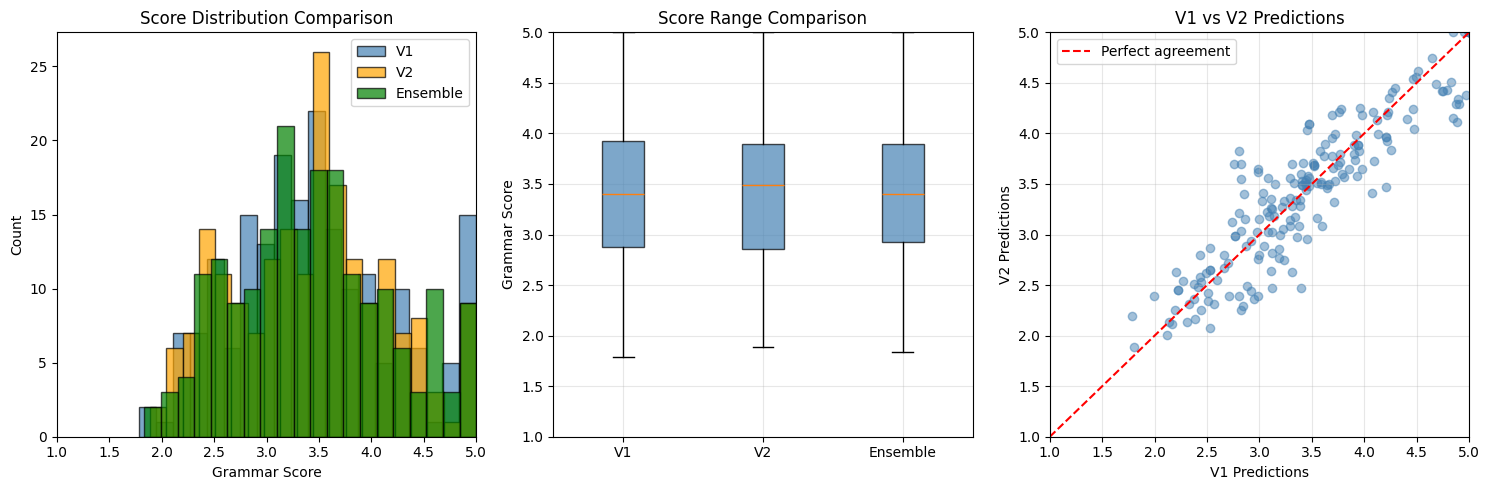

SUBMISSION COMPARISON
V1 Mean: 3.441 | Kaggle RMSE: 0.629
V2 Mean: 3.422 | Kaggle RMSE: 0.644
Ensemble Mean: 3.433 | Kaggle RMSE: 0.617
Best: Ensemble with RMSE 0.617


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

v1 = pd.read_csv("submission_v1 (1).csv")
v2 = pd.read_csv("submission_v2.csv")
ensemble = pd.read_csv("submission_ensemble.csv")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(v1['label'], bins=20, alpha=0.7, color='steelblue', edgecolor='black', label='V1')
plt.hist(v2['label'], bins=20, alpha=0.7, color='orange', edgecolor='black', label='V2')
plt.hist(ensemble['label'], bins=20, alpha=0.7, color='green', edgecolor='black', label='Ensemble')
plt.title('Score Distribution Comparison')
plt.xlabel('Grammar Score')
plt.ylabel('Count')
plt.xlim(1, 5)
plt.legend()

plt.subplot(1, 3, 2)
plt.boxplot(
    [v1['label'], v2['label'], ensemble['label']],
    tick_labels=['V1', 'V2', 'Ensemble'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.7)
)
plt.title('Score Range Comparison')
plt.ylabel('Grammar Score')
plt.ylim(1, 5)
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(v1['label'], v2['label'], alpha=0.5, color='steelblue')
plt.plot([1, 5], [1, 5], 'r--', label='Perfect agreement')
plt.xlabel('V1 Predictions')
plt.ylabel('V2 Predictions')
plt.title('V1 vs V2 Predictions')
plt.xlim(1, 5)
plt.ylim(1, 5)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('submission_comparison.png', dpi=150)
plt.show()

print("SUBMISSION COMPARISON")
print("V1 Mean:", round(v1['label'].mean(), 3), "| Kaggle RMSE: 0.629")
print("V2 Mean:", round(v2['label'].mean(), 3), "| Kaggle RMSE: 0.644")
print("Ensemble Mean:", round(ensemble['label'].mean(), 3), "| Kaggle RMSE: 0.617")
print("Best: Ensemble with RMSE 0.617")

# Comparing actual training score distribution with model's predicted score distribution on test data.


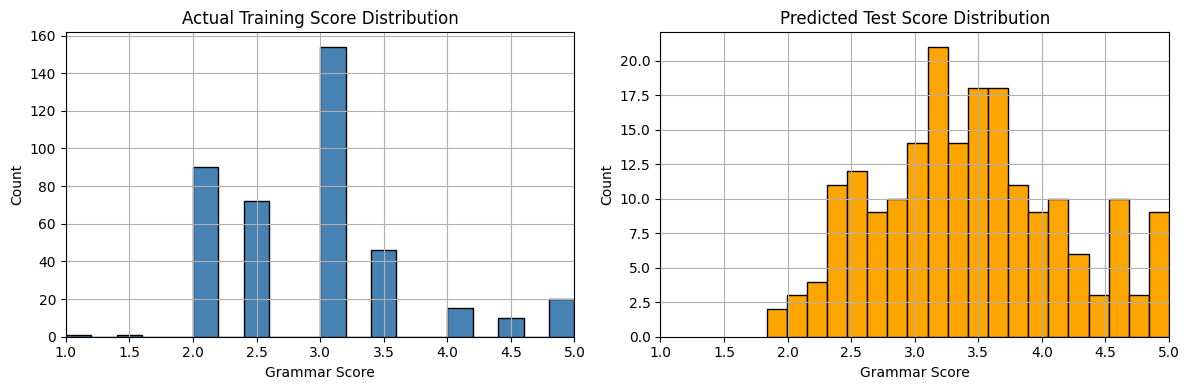

Training Mean: 2.911
Predicted Mean: 3.433
Training Std: 0.767
Predicted Std: 0.739


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

train_df = pd.read_csv("train.csv")
ensemble = pd.read_csv("submission_ensemble.csv")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
train_df['label'].hist(bins=20, color='steelblue', edgecolor='black')
plt.title('Actual Training Score Distribution')
plt.xlabel('Grammar Score')
plt.ylabel('Count')
plt.xlim(1, 5)

plt.subplot(1, 2, 2)
ensemble['label'].hist(bins=20, color='orange', edgecolor='black')
plt.title('Predicted Test Score Distribution')
plt.xlabel('Grammar Score')
plt.ylabel('Count')
plt.xlim(1, 5)

plt.tight_layout()
plt.show()

print("Training Mean:", round(train_df['label'].mean(), 3))
print("Predicted Mean:", round(ensemble['label'].mean(), 3))
print("Training Std:", round(train_df['label'].std(), 3))
print("Predicted Std:", round(ensemble['label'].std(), 3))





### Distribution Analysis Insights

- Training mean (2.911) vs Predicted mean (3.433) shows the model has a slight upward bias
- Standard deviation is similar (0.767 vs 0.739) indicating the model captures score spread well
- Both distributions peak around 3.0-3.5 which aligns with expected grammar score patterns
- The upward bias may explain our RMSE score of 0.617